First few rows of the dataset:


,date,jackpot,numbers,num_winners,prizes
0,"Wed, Jan 1, 2020",$222 Million,"['49', '53', '57', '59', '62', '26']",[],[]
1,"Wed, Jan 1, 2020",$222 Million,"['49', '53', '57', '59', '62', '26']",['0'],['Grand Prize']
2,"Wed, Jan 1, 2020",$222 Million,"['49', '53', '57', '59', '62', '26']",['1'],"['$1,000,000']"
3,"Wed, Jan 1, 2020",$222 Million,"['49', '53', '57', '59', '62', '26']",['12'],"['$50,000']"
4,"Wed, Jan 1, 2020",$222 Million,"['49', '53', '57', '59', '62', '26']",['399'],['$100']



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17890 entries, 0 to 17889
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         17890 non-null  object
 1   jackpot      17890 non-null  object
 2   numbers      17890 non-null  object
 3   num_winners  17890 non-null  object
 4   prizes       17890 non-null  object
dtypes: object(5)
memory usage: 349.5+ KB

Duplicate Entries:
11090
Number of rows after removing duplicates: 6800
        jackpot  jackpot_cleaned
0  $222 Million            222.0
1  $222 Million            222.0
2  $222 Million            222.0
3  $222 Million            222.0
4  $222 Million            222.0
                                numbers            numbers_parsed
0  ['49', '53', '57', '59', '62', '26']  [49, 53, 57, 59, 62, 26]
1  ['49', '53', '57', '59', '62', '26']  [49, 53, 57, 59, 62, 26]
2  ['49', '53', '57', '59', '62', '26']  [49, 53, 57, 59, 62, 26]
3  ['4

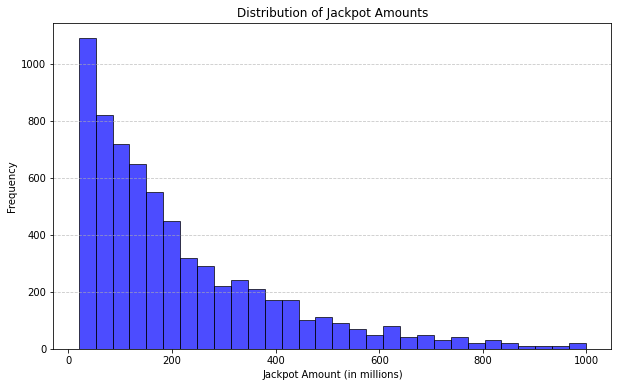

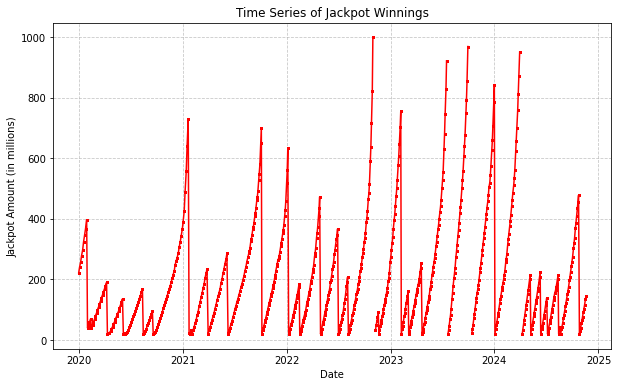

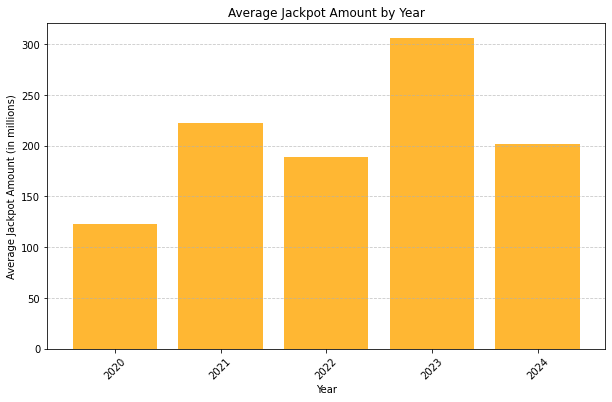

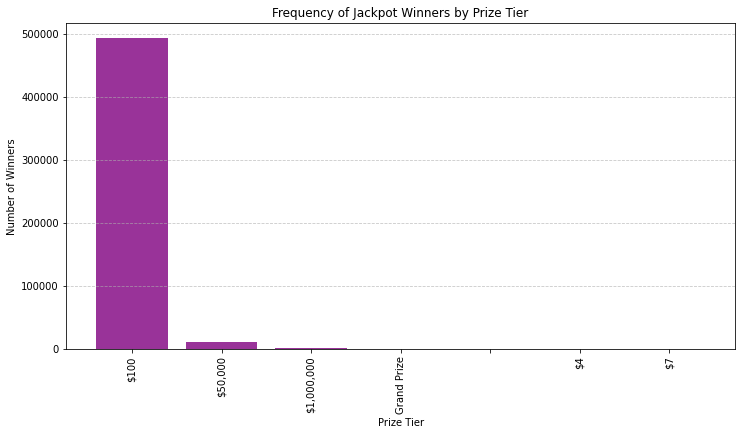

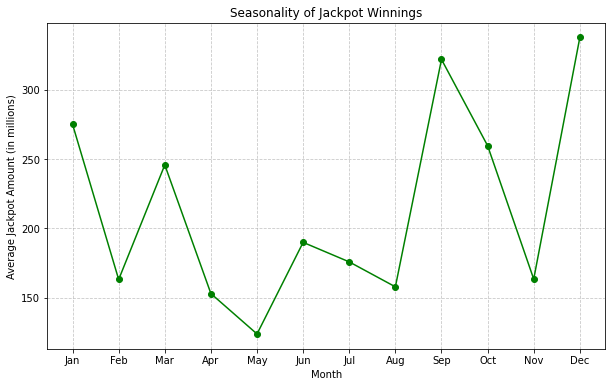

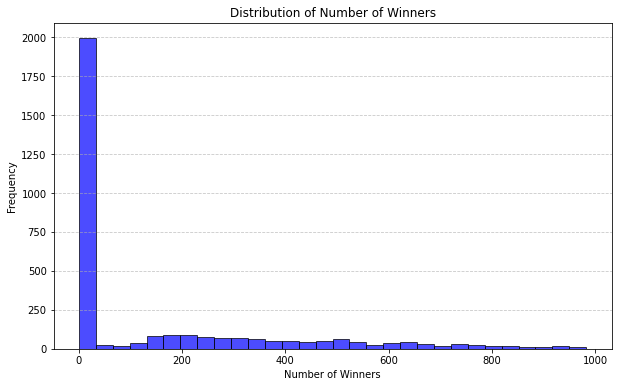

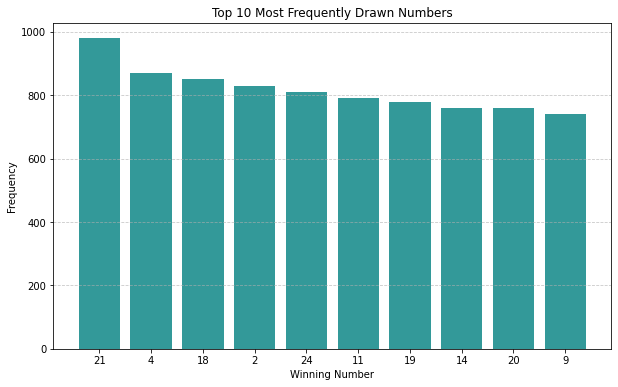

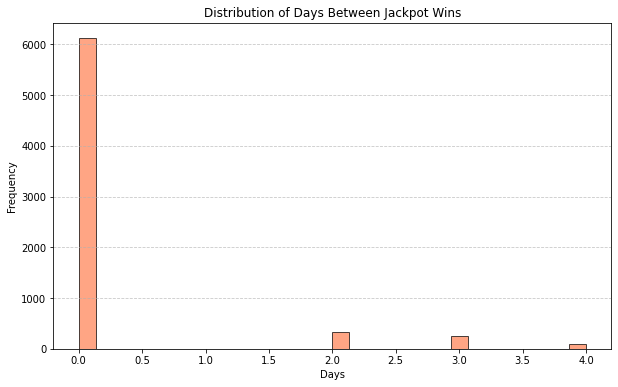

In [1]:


import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r"C:\Users\Samantha Townsend\Downloads\2020-to-2025-powerball_data - Sheet1 - 2020-to-2025-powerball_data - Sheet1.csv" 
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("First few rows of the dataset:")
display(data.head())

# Data Overview
print("\nDataset Information:")
data.info()

# Check for duplicates
print("\nDuplicate Entries:")
print(data.duplicated().sum())





# Cleaning
# Remove duplicate rows
data = data.drop_duplicates()

# Verify the removal of duplicates
print(f"Number of rows after removing duplicates: {len(data)}")

# Function to clean jackpot values
def clean_jackpot(value):
    value = value.replace('$', '').replace('Million', '').strip()
    try:
        return float(value)
    except ValueError:
        return None

# Apply the cleaning function
data['jackpot_cleaned'] = data['jackpot'].apply(clean_jackpot)

# Check cleaned jackpot values
print(data[['jackpot', 'jackpot_cleaned']].head())

# Function to parse list-like strings
def parse_list_column(column):
    return column.str.strip("[]").str.replace("'", "").str.split(", ")

# Apply parsing
data['numbers_parsed'] = parse_list_column(data['numbers'])
data['num_winners_parsed'] = parse_list_column(data['num_winners'])
data['prizes_parsed'] = parse_list_column(data['prizes'])

# Check parsed columns
print(data[['numbers', 'numbers_parsed']].head())
print(data[['num_winners', 'num_winners_parsed']].head())
print(data[['prizes', 'prizes_parsed']].head())

# Convert date column to datetime
data['date_cleaned'] = pd.to_datetime(data['date'], errors='coerce')

# Verify cleaned dates
print(data[['date', 'date_cleaned']].head())




import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data['jackpot_cleaned'].dropna(), bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Jackpot Amounts')
plt.xlabel('Jackpot Amount (in millions)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




# Sort data by cleaned date
data = data.sort_values('date_cleaned')

plt.figure(figsize=(10, 6))
plt.plot(data['date_cleaned'], data['jackpot_cleaned'], color='red', marker='o', linestyle='-', markersize=2)
plt.title('Time Series of Jackpot Winnings')
plt.xlabel('Date')
plt.ylabel('Jackpot Amount (in millions)')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()




# Extract year from cleaned date
data['year'] = data['date_cleaned'].dt.year

# Calculate average jackpot per year
average_jackpot_per_year = data.groupby('year')['jackpot_cleaned'].mean()

# Plot average jackpot per year
plt.figure(figsize=(10, 6))
plt.bar(average_jackpot_per_year.index, average_jackpot_per_year.values, color='orange', alpha=0.8)
plt.title('Average Jackpot Amount by Year')
plt.xlabel('Year')
plt.ylabel('Average Jackpot Amount (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




# Explode the 'prizes_parsed' column
prizes_exploded = data.explode('prizes_parsed')

# Explode the 'num_winners_parsed' column
winners_exploded = prizes_exploded.explode('num_winners_parsed')

# Clean and convert the exploded 'num_winners_parsed' column to numeric
winners_exploded['num_winners_parsed'] = pd.to_numeric(winners_exploded['num_winners_parsed'], errors='coerce')

# Group by 'prizes_parsed' and count the total winners
winners_by_prize = winners_exploded.groupby('prizes_parsed')['num_winners_parsed'].sum().sort_values(ascending=False)

# Plot the total winners by prize tier
plt.figure(figsize=(12, 6))
plt.bar(winners_by_prize.index, winners_by_prize.values, color='purple', alpha=0.8)
plt.title('Frequency of Jackpot Winners by Prize Tier')
plt.xlabel('Prize Tier')
plt.ylabel('Number of Winners')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



# Extract month from cleaned date
data['month'] = data['date_cleaned'].dt.month

# Calculate average jackpot by month
average_jackpot_per_month = data.groupby('month')['jackpot_cleaned'].mean()

# Plot average jackpot by month
plt.figure(figsize=(10, 6))
plt.plot(average_jackpot_per_month.index, average_jackpot_per_month.values, marker='o', linestyle='-', color='green')
plt.title('Seasonality of Jackpot Winnings')
plt.xlabel('Month')
plt.ylabel('Average Jackpot Amount (in millions)')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()




# Explode the 'prizes_parsed' column
data_exploded = data.explode('prizes_parsed')

# Explode the 'num_winners_parsed' column
data_exploded = data_exploded.explode('num_winners_parsed')

# Convert the exploded 'num_winners_parsed' column to numeric
data_exploded['num_winners_parsed'] = pd.to_numeric(data_exploded['num_winners_parsed'], errors='coerce')

# Plot the distribution of number of winners
plt.figure(figsize=(10, 6))
plt.hist(data_exploded['num_winners_parsed'].dropna(), bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Number of Winners')
plt.xlabel('Number of Winners')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




# Flatten the numbers column
data_numbers_exploded = data.explode('numbers_parsed')

# Count frequency of each number
number_frequency = data_numbers_exploded['numbers_parsed'].value_counts()

# Plot the top 10 most frequently drawn numbers
top_numbers = number_frequency.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_numbers.index, top_numbers.values, color='teal', alpha=0.8)
plt.title('Top 10 Most Frequently Drawn Numbers')
plt.xlabel('Winning Number')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




# Calculate the time difference between consecutive jackpot wins
data['days_between_jackpots'] = data['date_cleaned'].diff().dt.days

# Plot the time difference distribution
plt.figure(figsize=(10, 6))
plt.hist(data['days_between_jackpots'].dropna(), bins=30, color='coral', alpha=0.7, edgecolor='black')
plt.title('Distribution of Days Between Jackpot Wins')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [8]:
import random
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt

# Load the cleaned dataset
file_path = r"C:\Users\Samantha Townsend\Downloads\2020-to-2025-powerball_data - Sheet1 - 2020-to-2025-powerball_data - Sheet1.csv"
data = pd.read_csv(file_path)

# Parse and clean numbers column
data['numbers_parsed'] = data['numbers'].str.strip("[]").str.replace("'", "").str.split(", ")
data_numbers_exploded = data.explode('numbers_parsed')
data_numbers_exploded['numbers_parsed'] = pd.to_numeric(data_numbers_exploded['numbers_parsed'], errors='coerce')

# Calculate frequency of each number
number_frequency = data_numbers_exploded['numbers_parsed'].value_counts()

# Define common_numbers and weights
common_numbers = number_frequency.index.tolist()
weights = number_frequency.values / number_frequency.sum()  # Normalize frequencies to probabilities

# Helper function to split numbers into odd/even
def split_odd_even(numbers):
    odd = [num for num in numbers if num % 2 != 0]
    even = [num for num in numbers if num % 2 == 0]
    return odd, even

# Powerball number generator function
def generate_powerball_numbers(common_numbers, weights):
    max_attempts = 5000  # Limit the number of attempts to avoid infinite loops
    attempts = 0

    while attempts < max_attempts:
        selected = set()

        # Draw 5 unique numbers for white balls (1-69)
        while len(selected) < 5:
            candidate = random.choices(common_numbers, weights=weights, k=1)[0]

            # Avoid adding duplicates
            if candidate in selected:
                continue

            # Avoid too many consecutive numbers (relaxed)
            if any(abs(candidate - num) == 1 for num in selected) and len(selected) >= 4:
                continue

            selected.add(candidate)

        white_balls = sorted(selected)

        # Relaxed Odd/Even Constraint: Require at least one of each
        odd, even = split_odd_even(white_balls)
        if len(odd) < 1 or len(even) < 1:  # At least one odd and one even
            attempts += 1
            continue

        # Draw a red Powerball (1-26)
        red_ball = random.randint(1, 26)

        return white_balls, red_ball

    raise ValueError(f"Failed to generate valid Powerball numbers within {max_attempts} attempts.")

# Call the generator function with common_numbers and weights
try:
    white_balls, red_ball = generate_powerball_numbers(common_numbers, weights)
    print(f"Generated Powerball Numbers: {white_balls} + Powerball: {red_ball}")
except ValueError as e:
    print(e)


Generated Powerball Numbers: [13, 28, 38, 41, 46] + Powerball: 10


Generated Powerball Numbers: [7, 24, 40, 51, 57] + Powerball: 16
